<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Rnn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

torch.__version__

'2.10.0+cpu'

In [2]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/andresca94/MasterCard-Stock-Price-Prediction-Using-LSTM-and-GRU/refs/heads/main/Mastercard_stock_history.csv", index_col="Date", date_format="Date")
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2006-05-25,3.748967,4.283869,3.739664,4.279217,395343000,0.0,0.0
2006-05-26,4.307126,4.348058,4.103398,4.179680,103044000,0.0,0.0
2006-05-30,4.183400,4.184330,3.986184,4.093164,49898000,0.0,0.0
2006-05-31,4.125723,4.219679,4.125723,4.180608,30002000,0.0,0.0
2006-06-01,4.179678,4.474572,4.176887,4.419686,62344000,0.0,0.0


In [3]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3872.000000,3872.000000,3872.000000,3872.000000,3.872000e+03,3872.000000,3872.000000
mean,104.896814,105.956054,103.769349,104.882714,1.232250e+07,0.002329,0.002583
std,106.245511,107.303589,105.050064,106.168693,1.759665e+07,0.025851,0.160706
min,3.748967,4.102467,3.739664,4.083861,6.411000e+05,0.000000,0.000000
25%,22.347203,22.637997,22.034458,22.300391,3.529475e+06,0.000000,0.000000
50%,70.810079,71.375896,70.224002,70.856083,5.891750e+06,0.000000,0.000000
75%,147.688448,148.645373,146.822013,147.688438,1.319775e+07,0.000000,0.000000
max,392.653890,400.521479,389.747812,394.685730,3.953430e+08,0.440000,10.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3872 entries, 2006-05-25 to 2021-10-11
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          3872 non-null   float64
 1   High          3872 non-null   float64
 2   Low           3872 non-null   float64
 3   Close         3872 non-null   float64
 4   Volume        3872 non-null   int64  
 5   Dividends     3872 non-null   float64
 6   Stock Splits  3872 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 242.0+ KB


In [5]:
starting_date = 2012
ending_date = 2016

In [6]:
data = df.loc[f"{starting_date}" : f"{ending_date}", "Open"]
data

,Open
Date,
2012-01-03,35.788398
2012-01-04,34.520952
2012-01-05,33.478526
2012-01-06,33.436895
2012-01-09,32.633512
...,...
2015-12-24,95.221373
2015-12-28,94.614085
2015-12-29,95.655157


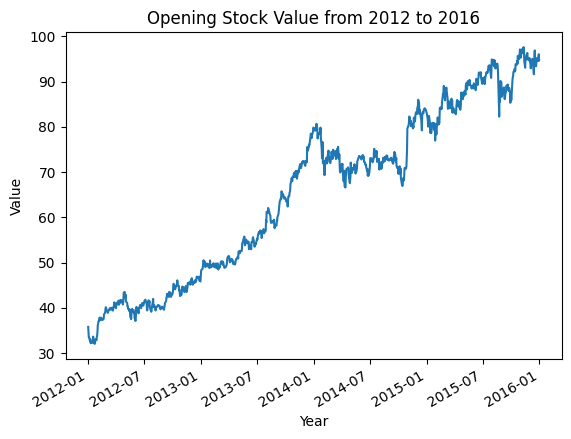

In [7]:
import matplotlib.pyplot as plt

plt.plot(pd.to_datetime(data.index), data.values)
plt.gcf().autofmt_xdate()
plt.title("Opening Stock Value from 2012 to 2016")
plt.xlabel("Year")
plt.ylabel("Value")
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scalled_data = scaler.fit_transform(data.values.reshape(-1, 1))

In [9]:
scalled_data

array([[-1.58309792],
       [-1.65037386],
       [-1.7057058 ],
       ...,
       [ 1.59462643],
       [ 1.61714089],
       [ 1.54448237]])

In [10]:
scalled_data.shape

(1006, 1)

In [11]:
import numpy as np

x = []
y = []
window_size = 60

for i in range(window_size, len(scalled_data)):
    x.append(scalled_data[i - window_size : i, 0])
    y.append(scalled_data[i, 0])

X, Y = np.array(x), np.array(y)

In [12]:
X, Y[:5]

(array([[-1.58309792, -1.65037386, -1.7057058 , ..., -1.33658595,
         -1.29529937, -1.3038889 ],
        [-1.65037386, -1.7057058 , -1.70791556, ..., -1.29529937,
         -1.3038889 , -1.34999698],
        [-1.7057058 , -1.70791556, -1.75055907, ..., -1.3038889 ,
         -1.34999698, -1.32985584],
        ...,
        [ 1.07721537,  1.25701912,  1.31882682, ...,  1.52861935,
          1.57160119,  1.53936636],
        [ 1.25701912,  1.31882682,  1.35311532, ...,  1.57160119,
          1.53936636,  1.59462643],
        [ 1.31882682,  1.35311532,  1.36283699, ...,  1.53936636,
          1.59462643,  1.61714089]]),
 array([-1.34999698, -1.32985584, -1.36395992, -1.31438571, -1.29942983]))

In [13]:
X.shape[0], X.shape[1]

(946, 60)

In [14]:
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [15]:
X.shape

(946, 60, 1)

In [16]:
X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(Y).float()

In [17]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2)

In [18]:
len(x_train), len(x_test)

(756, 190)

In [19]:
from torch import nn

class RNN_Model(nn.Module):
    def __init__(self, input_units, output_units, hidden_units):
        super(RNN_Model, self).__init__()
        self.rnn = nn.RNN(input_units, hidden_units, batch_first=True)
        self.linear = nn.Linear(hidden_units, output_units)
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.linear(out[:,-1,:])
        return out

model = RNN_Model(input_units=1, hidden_units=32, output_units=1)
model

RNN_Model(
  (rnn): RNN(1, 32, batch_first=True)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)

In [20]:
prediction = model(x_train)
print(prediction.shape)

torch.Size([756, 1])


In [21]:
from torch.optim import Adam
from torch.nn import MSELoss

criterion = MSELoss()
optimizer = Adam(model.parameters(), lr=0.001)

for epoch in range(1000):

    pred = model(x_train)
    loss = criterion(pred, y_train.unsqueeze(1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch} Loss: {loss.item():.5f}")

Epoch 0 Loss: 0.84497
Epoch 100 Loss: 0.00865
Epoch 200 Loss: 0.00506
Epoch 300 Loss: 0.00432
Epoch 400 Loss: 0.00398
Epoch 500 Loss: 0.00377
Epoch 600 Loss: 0.00362
Epoch 700 Loss: 0.00349
Epoch 800 Loss: 0.00338
Epoch 900 Loss: 0.00328


In [22]:
X_test_pred = model(x_test)

In [29]:
X_test_pred_val = X_test_pred.detach().numpy()
type(X_test_pred_val)

numpy.ndarray

In [30]:
X_test_pred_val = scaler.inverse_transform(X_test_pred_val)

In [32]:
y_test_val = scaler.inverse_transform(y_test.reshape(-1, 1))

In [33]:
len(X_test_pred_val), len(y_test_val)

(190, 190)

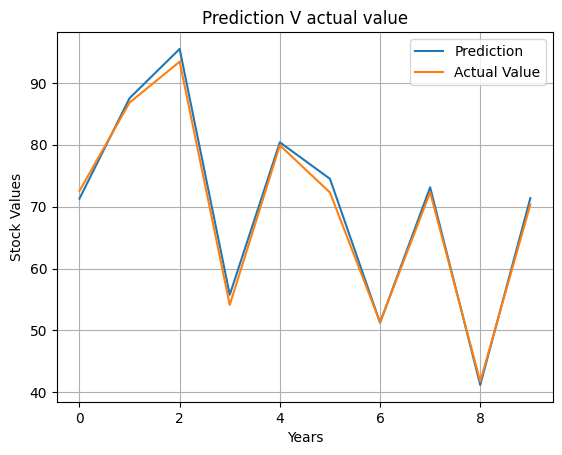

In [38]:
plt.plot(X_test_pred_val[:10], label="Prediction")
plt.plot(y_test_val[:10], label="Actual Value")
plt.xlabel("Years")
plt.ylabel("Stock Values")
plt.title("Prediction V actual value")
plt.grid()
plt.legend()
plt.show()